# PROYECTO DE CIENCIA DE DATOS
* Entrega 1
* Análisis Exploratorio de Datos (EDA)

In [1]:
# Importa el módulo 'drive' de la librería especial 'google.colab'
# Este módulo permite que Colab se conecte con tu Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Importa la librería pandas, que se usa para manipulación y análisis de datos
import pandas as pd

# Define la ruta del archivo CSV dentro de tu Google Drive montado en Colab
# En este caso, el archivo está en la carpeta 'proyecto' dentro de 'MyDrive'
path = '/content/drive/MyDrive/proyecto/bank-full.csv'

# Lee el archivo CSV usando pandas y lo guarda en el DataFrame 'df'
# El argumento sep=';' indica que las columnas están separadas por punto y coma
df = pd.read_csv(path, sep=';')
df.head()# Muestra las primeras 5 filas del DataFrame para verificar que se cargó correctamente

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# 1. **Objetivos y alcances**

- **Objetivo General:** Desarrollar un modelo de clasificación que permita identificar el perfil de clientes con mayor probabilidad de contratar un depósito a plazo, optimizando así futuras campañas de marketing.

- **Descripción:** El dataset contiene información sociodemográfica, financiera y detalles del último contacto de la campaña.

# Ficha del Conjunto de Datos

| Aspecto | Información |
|---------|-------------|
| **Fuente de recolección y origen de los datos** | UCI Machine Learning Repository (Bank Marketing Dataset) |
| **Nombre del conjunto de datos utilizado** | Bank Marketing |
| **Institución que creó el conjunto de datos?** | Universidad de Coimbra en Portugal |
| **Propósito de la cración** | Predecir la suscripción de plazo fijo de clientes a partir de campañas de marketing telefónico |
| **Mecanismos o procedimientos para recoger los datos** | Contactos telefónicos directos durante campañas de marketing |
| **Existe documentación de información del conjunto de datos** | Sí, disponible en el repositorio de UCI Machine Learning Repository |

#  Diccionario de variables (Bank Marketing)
## Analisis EDA, (Exploracion de datos, con esto analisamos las variables y su significado)

| Variable  | Traducción          | Rol     | Tipo de variable | Descripción                                                    |
| --------- | ------------------- | ------- | ---------------- | -------------------------------------------------------------- |
| age       | edad                | Feature | Cuantitativa     | Edad del cliente                                               |
| balance   | saldo               | Feature | Cuantitativa     | Saldo promedio anual del cliente                               |
| duration  | duración            | Feature | Cuantitativa     | Duración de la llamada en segundos                             |
| campaign  | campaña             | Feature | Cuantitativa     | Cantidad de contactos en la campaña actual                     |
| pdays     | días desde contacto | Feature | Cuantitativa     | Días desde el último contacto (-1 = no contactado previamente) |
| previous  | contactos previos   | Feature | Cuantitativa     | Cantidad de contactos previos                                  |
| day       | día                 | Feature | Cuantitativa     | Día del mes en que se realizó el contacto                      |
| job       | trabajo             | Feature | Cualitativa      | Tipo de trabajo del cliente                                    |
| marital   | estado civil        | Feature | Cualitativa      | Estado civil del cliente                                       |
| education | educación           | Feature | Cualitativa      | Nivel educativo                                                |
| default   | en mora             | Feature | Cualitativa      | Indica si tiene deuda en mora                                  |
| housing   | crédito vivienda    | Feature | Cualitativa      | Indica si tiene crédito hipotecario                            |
| loan      | préstamo            | Feature | Cualitativa      | Indica si tiene préstamo personal                              |
| contact   | tipo de contacto    | Feature | Cualitativa      | Medio de contacto                                              |
| month     | mes                 | Feature | Cualitativa      | Mes del contacto                                               |
| poutcome  | resultado previo    | Feature | Cualitativa      | Resultado de la campaña anterior                               |
| y         | resultado           | Target  | Cualitativa      | Indica si el cliente contrató (sí/no)                          |


In [5]:
df.shape   # cuantas filas y columnas tiene


(45211, 17)

In [6]:
df.info() # Da información general sobre el DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


# Analisis de estadistica descriptiva





In [7]:
df.describe() # Da un panel de estadistica univariable numerica


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [8]:
df.describe(include="all") # Da un panel de estadistica univariable ( de todas las variables)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


Identificar posible problemas con los datos


In [9]:
for column in df.columns:
  print(f"Columna {column}\n{df[column].unique()}\n")

Columna age
[58 44 33 47 35 28 42 43 41 29 53 57 51 45 60 56 32 25 40 39 52 46 36 49
 59 37 50 54 55 48 24 38 31 30 27 34 23 26 61 22 21 20 66 62 83 75 67 70
 65 68 64 69 72 71 19 76 85 63 90 82 73 74 78 80 94 79 77 86 95 81 18 89
 84 87 92 93 88]

Columna job
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

Columna marital
['married' 'single' 'divorced']

Columna education
['tertiary' 'secondary' 'unknown' 'primary']

Columna default
['no' 'yes']

Columna balance
[ 2143    29     2 ...  8205 14204 16353]

Columna housing
['yes' 'no']

Columna loan
['no' 'yes']

Columna contact
['unknown' 'cellular' 'telephone']

Columna day
[ 5  6  7  8  9 12 13 14 15 16 19 20 21 23 26 27 28 29 30  2  3  4 11 17
 18 24 25  1 10 22 31]

Columna month
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

Columna duration
[ 261  151   76 ... 1298 1246 1556]

Columna campaign
[ 1  2  

No hay valores faltantes pero hay valores ¨unknowm¨

In [10]:
(df == 'unknown').sum() # Cantidad de valores Unknown.

,0
age,0
job,288
marital,0
education,1857
default,0
balance,0
housing,0
loan,0
contact,13020
day,0


#Valores atipicos


Outliers

Los puntos que quedan fuera de los bigotes (menores a Q1 - 1.5·IQR o mayores a Q3 + 1.5·IQR) se consideran valores atípicos u outliers.

En el gráfico, esos aparecen como puntos individuales fuera de la caja y los bigotes.

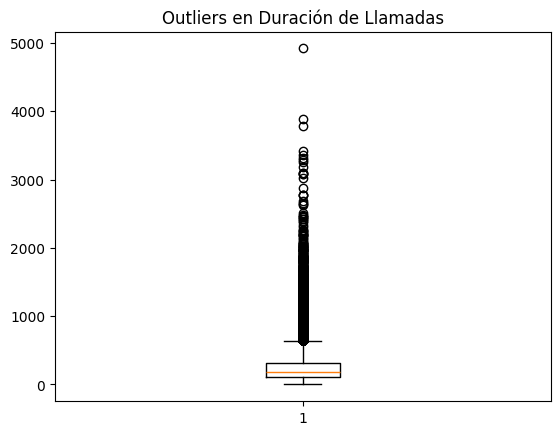

In [14]:
import matplotlib.pyplot as plt

plt.boxplot(df['duration'])
plt.title("Outliers en Duración de Llamadas")
plt.show()

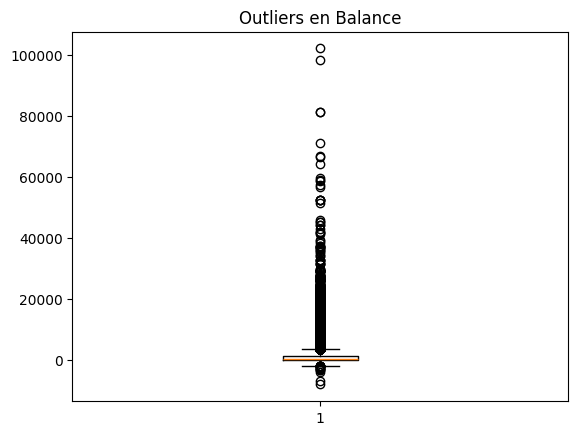

In [15]:
plt.boxplot(df['balance'])
plt.title("Outliers en Balance")
plt.show()

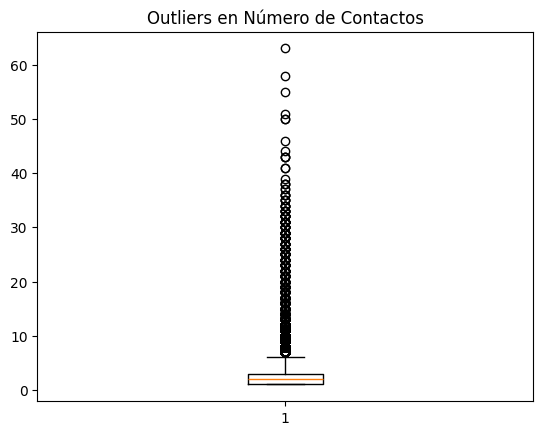

In [16]:
plt.boxplot(df['campaign'])
plt.title("Outliers en Número de Contactos")
plt.show()

Desbalance de la variable objetivo

In [17]:
df['y'].value_counts() # La variable objetivo es binaria y con esto obtenemos el balance de la misma

,count
y,
no,39922
yes,5289


Los valores negativos de la variable Balance significa que el

saldo promedio anual en la cuenta bancaria del cliente (en euros)

tiene deuda, su cuenta está en descubierto o con saldo negativo






In [18]:
df["balance"][df["balance"] < 0] # Muestra la ubicacion de los valores negativos

,balance
25,-372
28,-246
36,-7
37,-3
45,-171
...,...
44626,-205
44629,-46
44836,-195
44908,-130


# Preguntas de interés
1- ¿Qué perfil de cliente tiene mayor probabilidad de suscribirse a un depósito a plazo fijo?  
 Relacionar variables como edad, estado civil, educación, balance y duración de la llamada con la variable objetivo y.

2- ¿Influye la duración de la llamada en la tasa de éxito de la campaña?  
 Analizar si llamadas más largas tienden a terminar en suscripción, o si hay un punto óptimo de duración.

3- ¿Qué impacto tienen los contactos previos (campaign, previous, pdays) en la decisión del cliente?  
 Evaluar si insistir más veces mejora la tasa de conversión o si genera rechazo.

4- ¿Existen diferencias significativas según el tipo de trabajo o nivel educativo?  
 Comparar tasas de suscripción entre categorías de job y education para detectar segmentos más receptivos.

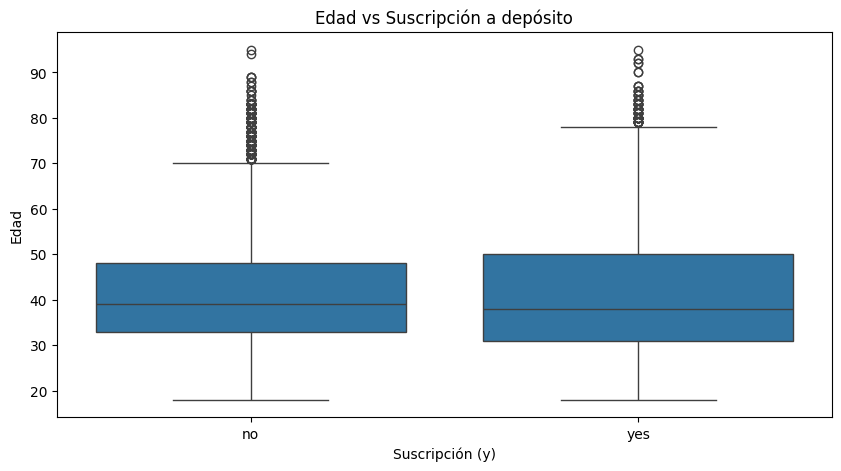

-
----------------------------------------
-


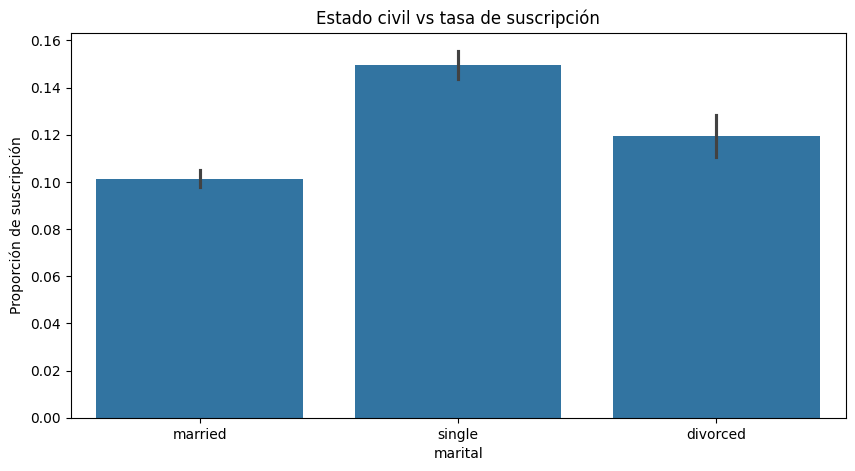

-
----------------------------------------
-


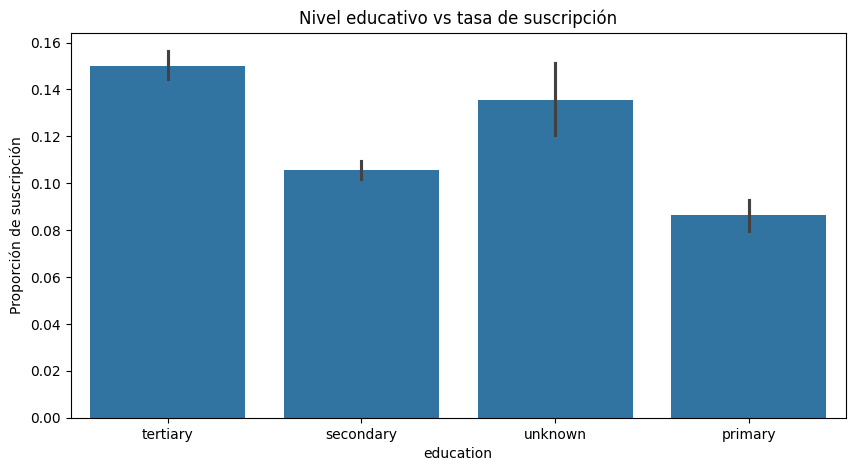

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Perfil de cliente con mayor probabilidad de suscribirse
# Relacionamos variables demográficas con la variable objetivo 'y'
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='age', data=df)
plt.title("Edad vs Suscripción a depósito")
plt.xlabel("Suscripción (y)")
plt.ylabel("Edad")
plt.show()
print("-")
print("-"*40)
print("-")

# barplot calcula la media de la variable
plt.figure(figsize=(10,5))
sns.barplot(x='marital', y=df['y'].apply(lambda x: 1 if x=='yes' else 0), data=df) # Con el lambda, convertimos esos valores en números: yes en 1 y no en 0
plt.title("Estado civil vs tasa de suscripción")
plt.ylabel("Proporción de suscripción")
plt.show()
print("-")
print("-"*40)
print("-")

plt.figure(figsize=(10,5))
sns.barplot(x='education', y=df['y'].apply(lambda x: 1 if x=='yes' else 0), data=df)
plt.title("Nivel educativo vs tasa de suscripción")
plt.ylabel("Proporción de suscripción")
plt.show()



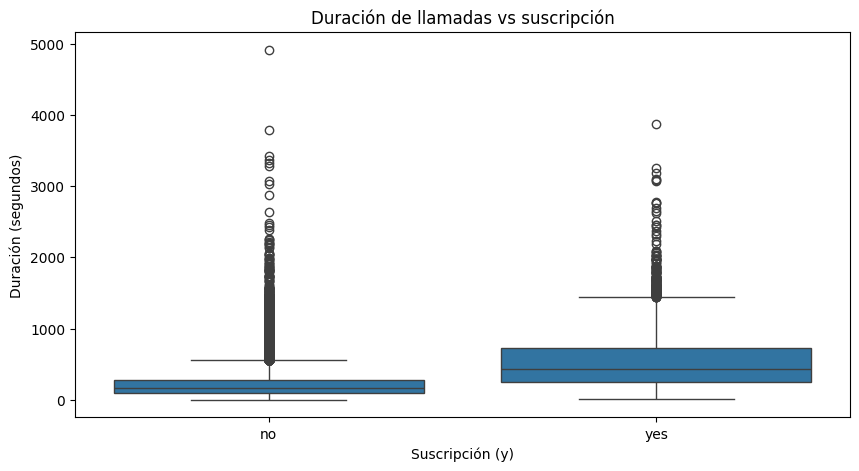

In [20]:
# 2. Duración de la llamada y tasa de éxito
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='duration', data=df)
plt.title("Duración de llamadas vs suscripción")
plt.xlabel("Suscripción (y)")
plt.ylabel("Duración (segundos)")
plt.show()



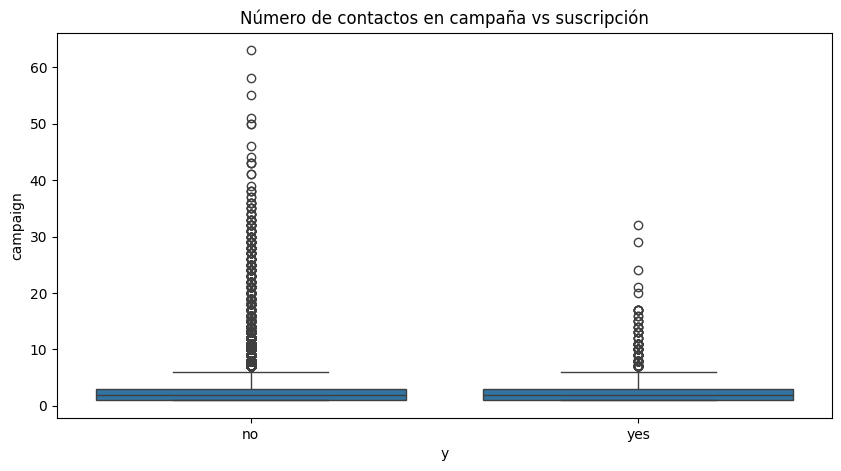

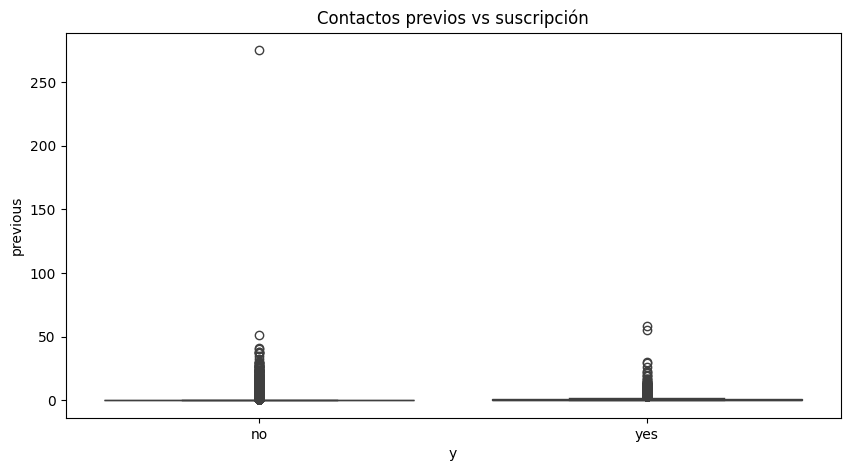

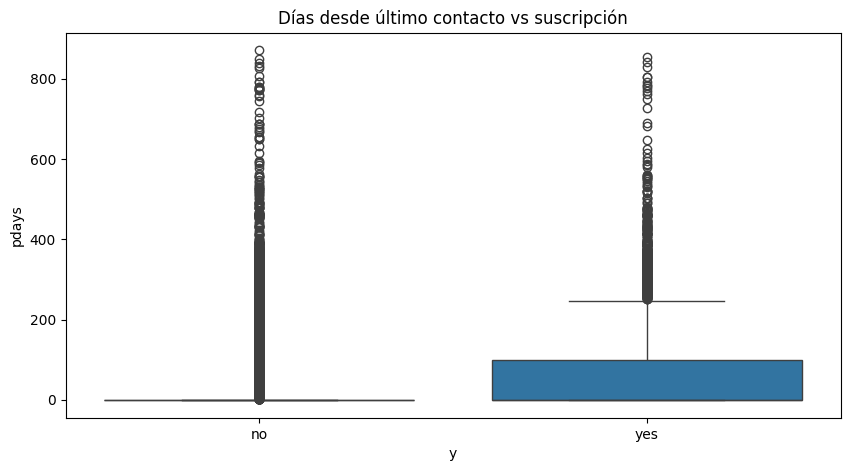

In [21]:
# 3. Impacto de contactos previos
plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='campaign', data=df)
plt.title("Número de contactos en campaña vs suscripción")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='previous', data=df)
plt.title("Contactos previos vs suscripción")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='y', y='pdays', data=df)
plt.title("Días desde último contacto vs suscripción")
plt.show()



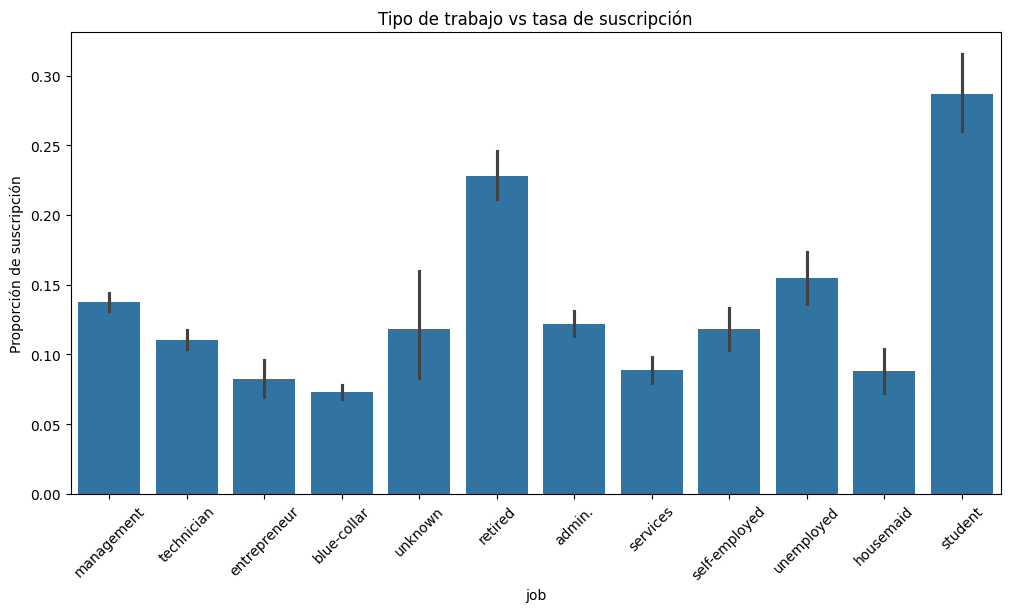

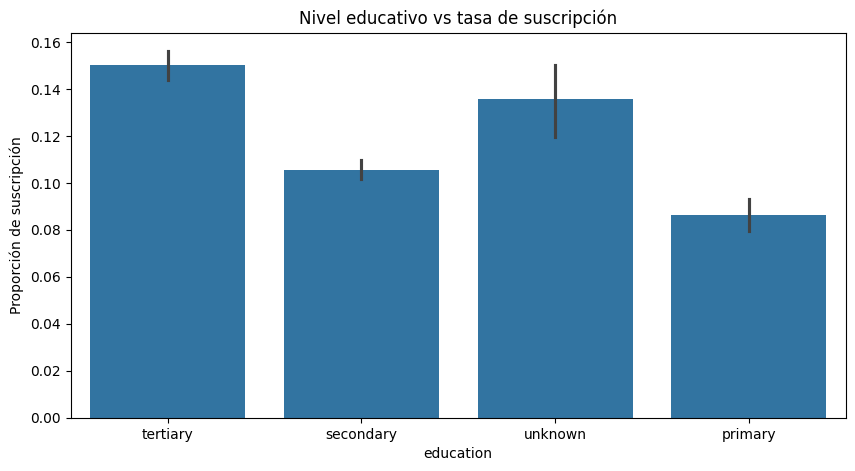

In [22]:
# 4. Diferencias según trabajo y educación
plt.figure(figsize=(12,6))
sns.barplot(x='job', y=df['y'].apply(lambda x: 1 if x=='yes' else 0), data=df)
plt.title("Tipo de trabajo vs tasa de suscripción")
plt.xticks(rotation=45)
plt.ylabel("Proporción de suscripción")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(x='education', y=df['y'].apply(lambda x: 1 if x=='yes' else 0), data=df)
plt.title("Nivel educativo vs tasa de suscripción")
plt.ylabel("Proporción de suscripción")
plt.show()



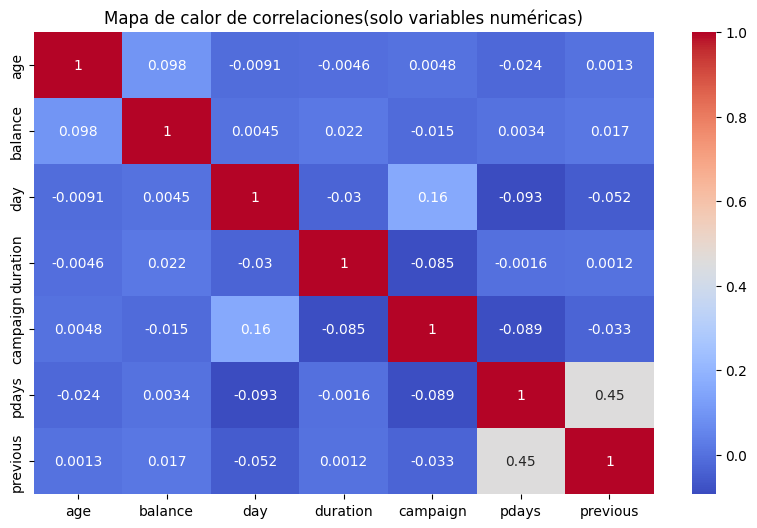

In [23]:
# 5. Correlación general entre variables numéricas
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Mapa de calor de correlaciones(solo variables numéricas)")
plt.show()

# Análisis de resultados de la campaña de marketing

## 1. Perfil de cliente con mayor probabilidad de suscribirse
- **Edad vs suscripción:** El boxplot muestra que los clientes que aceptan (*yes*) tienden a concentrarse en un rango etario específico, lo que indica que la edad influye en la receptividad.  
- **Estado civil:** El barplot refleja que ciertas categorías (ej. solteros o casados) presentan mayor proporción de aceptación, evidenciando diferencias en la tasa de éxito según estado civil.  
- **Nivel educativo:** El gráfico de educación muestra que niveles más altos de formación (ej. terciario/universitario) suelen tener mayor tasa de suscripción.  
 Estos gráficos responden a la pregunta porque permiten identificar **qué perfiles demográficos son más propensos a aceptar la oferta**.

---

## 2. Duración de la llamada y tasa de éxito
- **Duración vs suscripción:** El boxplot evidencia que las llamadas que terminan en *yes* suelen tener mayor duración que las que terminan en *no*.  
 Esto sugiere que **una interacción más prolongada con el cliente aumenta la probabilidad de conversión**, aunque también puede señalar un punto óptimo de duración.

---

## 3. Impacto de contactos previos
- **Campaign (número de contactos en campaña):** El boxplot muestra que los clientes que aceptan suelen tener menos intentos, lo que indica que insistir demasiado puede generar rechazo.  
- **Previous (contactos previos exitosos):** Los clientes con suscripciones positivas tienden a tener más antecedentes de interacción exitosa, lo que refuerza la importancia de un historial favorable.  
- **Pdays (días desde último contacto):** Valores bajos en clientes que aceptan sugieren que **contactar en intervalos cortos mejora la tasa de éxito**.  
 Estos gráficos responden a la pregunta mostrando cómo la **frecuencia y el historial de contactos influyen en la decisión del cliente**.

---

## 4. Diferencias según trabajo y educación
- **Job vs suscripción:** El barplot revela que ciertos tipos de trabajo (ej. management, estudiantes) presentan tasas de aceptación más altas, lo que permite identificar segmentos laborales más receptivos.  
- **Education vs suscripción:** El gráfico confirma que el nivel educativo también marca diferencias en la tasa de éxito, reforzando la segmentación por formación académica.  
 Responde a la pregunta porque permite **comparar segmentos y detectar cuáles son más proclives a aceptar la oferta**.

---

## 5. Correlación general entre variables numéricas
- **Mapa de calor de correlaciones:** El heatmap muestra relaciones entre variables como edad, balance, duración y número de contactos.  
- Permite identificar qué factores tienen mayor influencia sobre la variable objetivo `y`.  
 Complementa las respuestas anteriores al ofrecer una **visión global de las relaciones entre variables numéricas**.

---

###  Conclusión
Los cinco bloques de gráficos permiten responder de manera justificada las cuatro preguntas de interés:
1. Identificación de perfiles receptivos.  
2. Confirmación del impacto de la duración de la llamada.  
3. Evaluación del efecto de contactos previos.  
4. Comparación de diferencias por trabajo y educación.  
El heatmap aporta una visión transversal que refuerza la interpretación y da soporte estadístico a las conclusiones.


#  Conclusión del análisis exploratorio

El análisis inicial del conjunto de datos permitió extraer información relevante y detectar tanto fortalezas como limitaciones para su uso en el proyecto de ciencia de datos.

- **Información relevante:**
  - Se identificaron variables demográficas y de campaña (edad, estado civil, educación, balance, duración de llamada, número de contactos, historial previo) que muestran relación con la variable objetivo `y` (suscripción a depósito).
  - Los gráficos de barras, boxplots y mapas de calor evidenciaron patrones claros: mayor duración de llamadas y ciertos perfiles (por edad, educación o tipo de trabajo) se asocian con mayor probabilidad de aceptación.
  - El heatmap de correlaciones brindó una visión global de las relaciones entre variables numéricas, confirmando cuáles tienen mayor influencia sobre la decisión del cliente.

- **Facilidades:**
  - El dataset está estructurado y puede cargarse sin inconvenientes con Pandas.
  - La combinación de variables cualitativas y cuantitativas permite aplicar tanto análisis descriptivo como modelos predictivos.
  - Las librerías Matplotlib y Seaborn ofrecen visualizaciones claras que facilitan la interpretación y comunicación de resultados.

- **Dificultades:**
  - Se detectaron posibles valores atípicos (ej. duración de llamadas extremadamente largas) que pueden distorsionar el análisis.
  - Existen variables con valores faltantes o categorías poco representadas, lo que requiere limpieza y tratamiento previo.
  - La variable objetivo presenta cierto desbalance entre clases (*yes/no*), lo que puede afectar la calidad de modelos predictivos si no se aplican técnicas de balanceo.

###  Síntesis
Este primer análisis confirma que el conjunto de datos es adecuado para responder preguntas de interés sobre el perfil de clientes y la efectividad de las campañas. Sin embargo, será necesario aplicar técnicas de preprocesamiento (tratamiento de outliers, imputación de faltantes, balanceo de clases) para garantizar resultados robustos en etapas posteriores del proyecto.
